# Simple plots for GRL paper

In [5]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from scipy.stats import linregress
from scipy.stats import norm
from scipy.stats import gaussian_kde

import statsmodels.api as sm

In [6]:
global_dpath = '~/work/hist_sst/data/'

In [7]:
ceres_tsel = slice(2001,2023)

# Functions

In [8]:
def hac_trend(y, years=None, maxlags=2):
    y = np.asarray(y, dtype=float)

    if years is None:
        years = np.arange(len(y), dtype=float)
    else:
        years = np.asarray(years, dtype=float)

    mask = np.isfinite(y) & np.isfinite(years)
    y = y[mask]
    years = years[mask]

    ## center time so the intercept is the value near the middle of the period
    t = years - years.mean()

    ## fit y = a + b*t
    X = sm.add_constant(t)
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

    trend_per_year = fit.params[1]
    se_per_year = fit.bse[1]

    trend_per_decade = 10 * trend_per_year
    se_per_decade = 10 * se_per_year

    return {
        "trend_per_decade": trend_per_decade,
        "se_per_decade": se_per_decade,
        "ci90_per_decade": (
            trend_per_decade - 1.645 * se_per_decade,
            trend_per_decade + 1.645 * se_per_decade,
        ),
        "fit": fit,
    }

# ERF

In [9]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'

In [10]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(2000,2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")

CPU times: user 1.08 s, sys: 1.41 s, total: 2.49 s
Wall time: 7.56 s


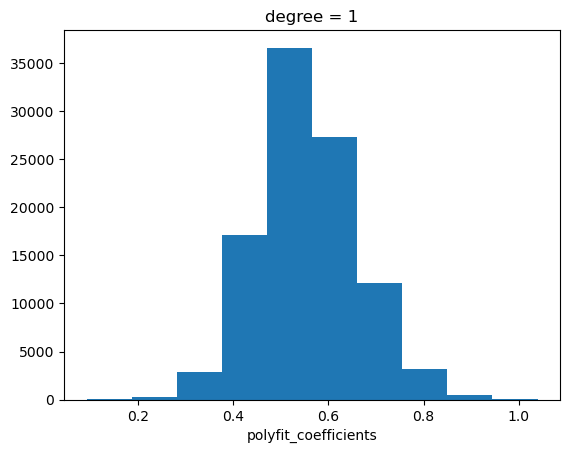

[0.398958   0.54754674 0.73782257]
<xarray.DataArray 'polyfit_coefficients' ()> Size: 8B
array(0.56)
Coordinates:
    degree   int64 8B 1 0.10401695441496547


In [11]:
dFdt = 10*erf_total.sel(time=ceres_tsel).polyfit(deg=1,dim='time').polyfit_coefficients[0]

dFdt.plot.hist()
plt.show()

print(dFdt.quantile([0.05,0.50, 0.95]).values)
print(dFdt.mean().round(2), dFdt.std().values)

In [12]:
## set parameters
dFdt_mu = dFdt.mean().values
dFdt_sig = dFdt.std(ddof=1).values
print(dFdt_mu.round(2), dFdt_sig.round(2))

0.56 0.1


## N (EEI): TOA imbalance

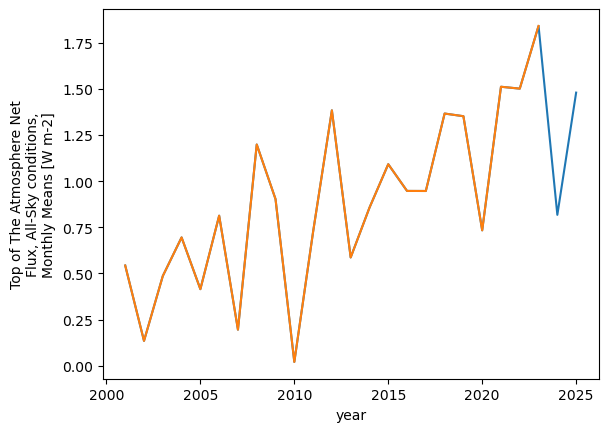

In [13]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01','2025-12-31')).groupby('time.year').mean()
ceres['gtoa_net_all_mon'].plot()

ceres['gtoa_net_all_mon'].sel(year=ceres_tsel).plot()

N = ceres['gtoa_net_all_mon'].sel(year=ceres_tsel)

plt.show()

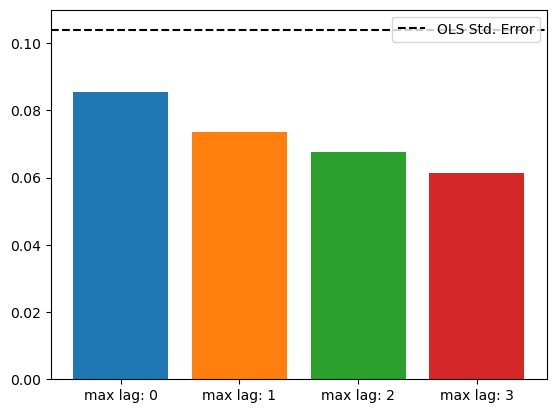

In [14]:
## no ensemble, so check std error of regression different ways

for i in np.arange(0,4,1):
    plt.bar(x='max lag: ' + str(i),height=hac_trend(N,maxlags=i)['se_per_decade'])

plt.axhline(linregress(N.year, N).stderr*10,c='k',label='OLS Std. Error',ls='--')
plt.legend()
plt.ylim(0,.11)
plt.show()

In [15]:
## set parameters
ols_N = linregress(N.year, N)
dNdt_mu = 10 * ols_N.slope
dNdt_sig = 10 * ols_N.stderr
print(dNdt_mu.round(2), dNdt_sig.round(2))

0.52 0.1


# Temperature

In [16]:
gmst_dict = {}

In [17]:
## Thorne
gmst_path = Path(global_dpath + "ar7-gmst-ensemble/sst_pseudo_ipcc.csv")

gmst_df = pd.read_csv(gmst_path, header=None)

gmst_ens = xr.DataArray(
    gmst_df.iloc[:, 1:].to_numpy(dtype="float32"),
    dims=("year", "ensemble"),
    coords={
        "year": gmst_df.iloc[:, 0].astype(int).to_numpy(),
        "ensemble": np.arange(gmst_df.shape[1] - 1),
    },
    name="gmst",
    attrs={"units": "degC", "baseline": "1850-1900"},
).sel(year=ceres_tsel)

gmst_dict['Thorne'] = gmst_ens

In [18]:
## HadCRUT5.1
## HadCRUT5 (should add)
path = global_dpath + 'other_recon/hadcrut5/'
fname = 'HadCRUT.5.1.0.0.analysis.ensemble_series.global.monthly.nc'
gmst_dict['HadCRUT5.1'] = (
    xr.open_dataset(path + fname)['tas']
    .sel(time=slice('2001-01-01','2025-12-31'))
    .groupby('time.year').mean().sel(year=ceres_tsel)
).rename({'realization':'ens'})

gmst_dict['HadCRUT5.1']

<xarray.DataArray 'tas' (ens: 200, year: 23)> Size: 37kB
array([[0.49662672, 0.53741708, 0.53343155, ..., 0.75296568, 0.76944539,
        1.10327949],
       [0.48377238, 0.51805041, 0.53147202, ..., 0.79115317, 0.7894848 ,
        1.10699201],
       [0.48640502, 0.53506828, 0.55500261, ..., 0.77603673, 0.8181999 ,
        1.10440103],
       ...,
       [0.50361812, 0.53349545, 0.54329597, ..., 0.79120943, 0.81511452,
        1.1149777 ],
       [0.48853593, 0.5338186 , 0.57660255, ..., 0.77438979, 0.81380523,
        1.09472718],
       [0.47725965, 0.54824253, 0.52117868, ..., 0.75325598, 0.83356543,
        1.11384827]], shape=(200, 23))
Coordinates:
  * ens        (ens) int64 2kB 1 2 3 4 5 6 7 8 ... 194 195 196 197 198 199 200
  * year       (year) int64 184B 2001 2002 2003 2004 ... 2020 2021 2022 2023
    latitude   float64 8B ...
    longitude  float64 8B ...
Attributes:
    long_name:     blended air_temperature_anomaly over land with sea_water_t...
    units:         K
    cell_methods:  area: mean (interval: 5.0 degrees_north 5.0 degrees_east) ...

In [19]:
## Cooper et al. 2025
path = global_dpath + 'public_share/ens_members/'
fname = 'ensmembers_tas_1850-2023.nc'
c25_load = xr.open_dataset(path + fname)['gmean'].sel(time=slice('2001-01-01','2024-01-01'))
c25_load = c25_load.rename({'ens':'ensemble'})
c25_tas = c25_load.groupby('time.year').mean(dim=['time']).stack(ens=['prior','ensemble'])

gmst_dict['C25'] = c25_tas


HadCRUT5.1
 0.22 0.006
0.211 0.219 0.229

Thorne
 0.229 0.013
0.214 0.226 0.252

C25
 0.239 0.022
0.203 0.24 0.28


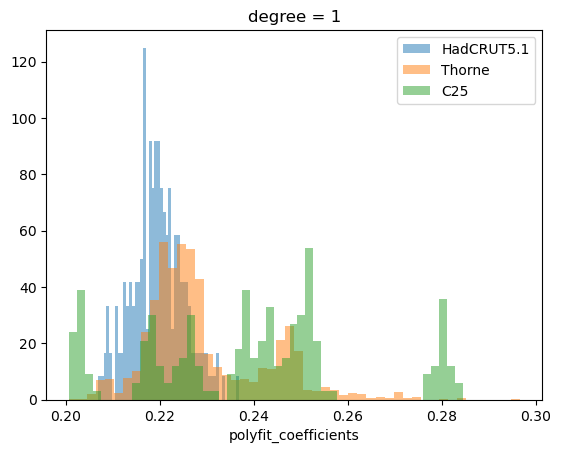

In [20]:
for key in ['HadCRUT5.1','Thorne','C25']:
    # dTdt = gmst_ens.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Thorne et al.',density=True)
    
    # dTdt = c25_tas.polyfit(deg=1,dim='year').polyfit_coefficients[0]
    # dTdt.plot.hist(bins=100,alpha=0.5,label='Cooper et al. 2025',density=True)
    
    dTdt = 10*gmst_dict[key].polyfit(deg=1,dim='year').polyfit_coefficients[0]
    dTdt.plot.hist(bins=50,alpha=0.5,label=key,density=True)

    print('\n' + key + '\n', dTdt.mean().round(3).values, dTdt.std(ddof=1).round(3).values)
    print(dTdt.quantile(0.05).round(3).values, dTdt.quantile(0.5).round(3).values, dTdt.quantile(0.95).round(3).values)
plt.legend()
plt.show()

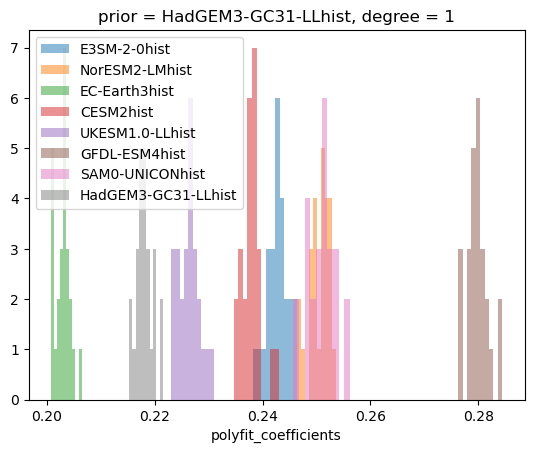

In [21]:
for i in range(8):
    temp = dTdt.unstack().isel(prior=i)
    temp.plot.hist(label=temp.prior.values,alpha=0.5)
plt.legend()
plt.show()

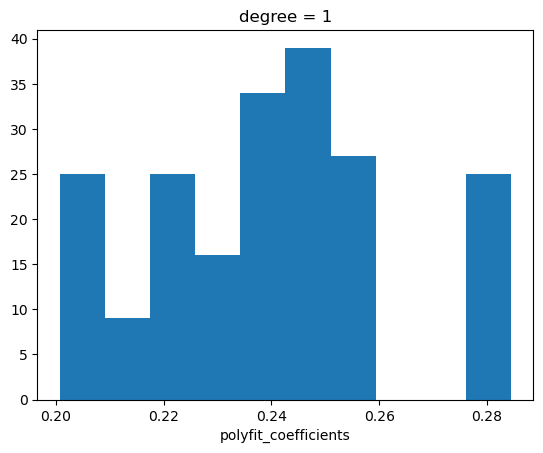

In [22]:
## choose middle
dTdt_mu  = 0.23
dTdt_sig = 0.013 # also matches BEST
dTdt.unstack().plot.hist()
plt.show()

# Pattern Effect

In [23]:
# from C25
dlamb_mu = 0.16 #median, mean is 0.136 for 2001-2023
dlamb_sig = 0.29 # all spread, including ic error
# cross model spread is ~0.15 #
#[should check cross model by doing cross model for the 3 BCs and pooling; could subtract IC spread]

# Monte Carlo

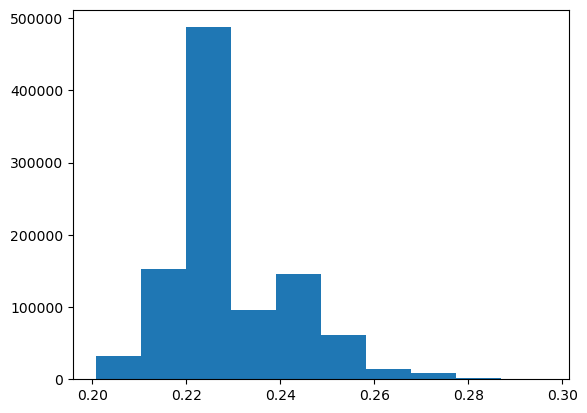

In [24]:
rng = np.random.default_rng(123)
mc_n = 1000000

## F2x
F2x_ens = rng.normal(loc= 3.93, scale=0.29, size=mc_n)

## T
Tin = 10*gmst_dict['Thorne'].polyfit(deg=1,dim='year').polyfit_coefficients[0]
Tdot_ens = rng.choice(Tin, size=mc_n, replace=True)
plt.hist(Tdot_ens)
plt.show()

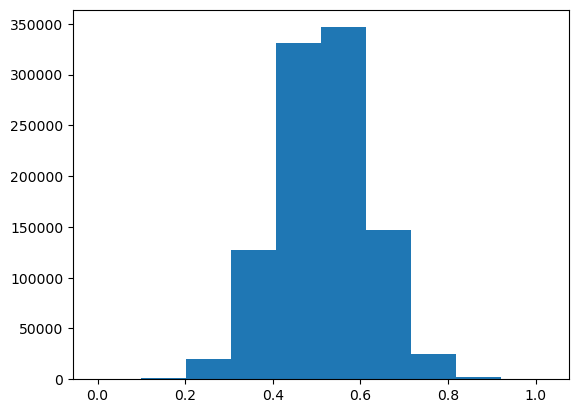

In [25]:
## N
Ndot_ens = rng.normal(loc=dNdt_mu, scale=dNdt_sig, size=mc_n)
plt.hist(Ndot_ens)
plt.show()

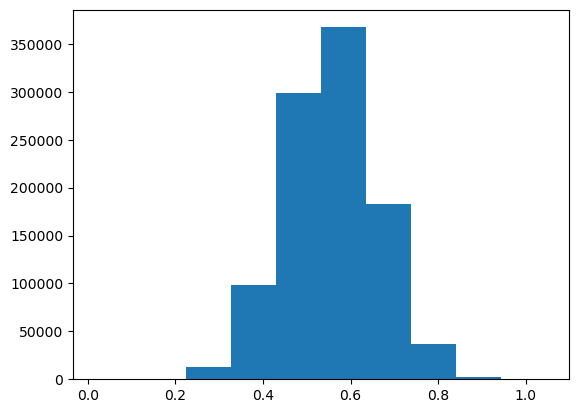

In [26]:
## F
Fdot_ens = rng.normal(loc=dFdt_mu, scale=dFdt_sig, size=mc_n)
plt.hist(Fdot_ens)
plt.show()

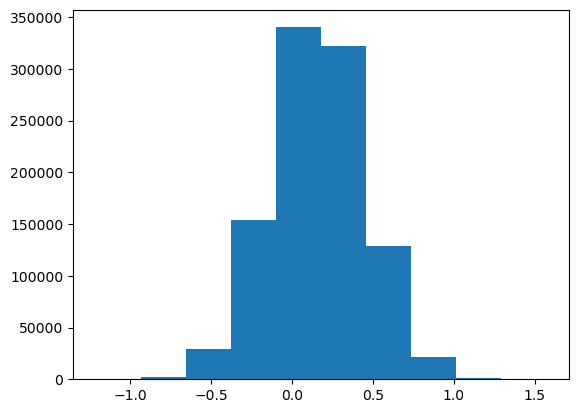

In [27]:
## dlamb
dlamb_ens = rng.normal(loc=dlamb_mu, scale=dlamb_sig, size=mc_n)
plt.hist(dlamb_ens)
plt.show()

In [28]:
## Likelihood

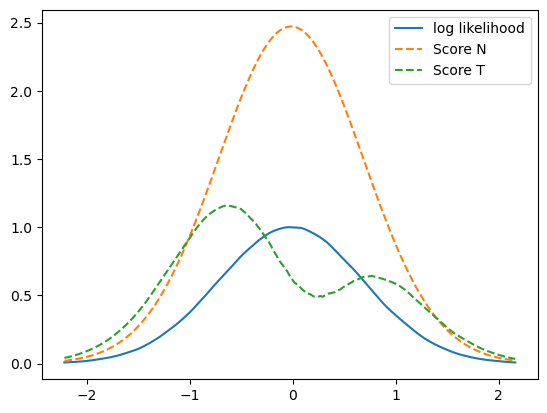

In [47]:
lam_ens = (Ndot_ens - Fdot_ens) / Tdot_ens + dlamb_ens
lam_ens = lam_ens[np.isfinite(lam_ens)]

kde = gaussian_kde(lam_ens)

lam_grid = np.linspace(*np.quantile(lam_ens, [0.001, 0.999]), 1000)
loglike = np.log(kde(lam_grid))
loglike -= loglike.max()  # optional normalization for plotting

In [45]:
%%time
### SCORE T version
### Score N version

like_N = np.zeros(len(lam_grid))
like_T = np.zeros(len(lam_grid))

for i,lam in enumerate(lam_grid):
    Npred = (lam - dlamb_ens)*Tdot_ens + Fdot_ens
    Tpred = (Ndot_ens - Fdot_ens)/(lam - dlamb_ens)
    like_N[i] = norm.pdf(Npred,loc=dNdt_mu,scale=dNdt_sig).mean()
    like_T[i] = norm.pdf(Tpred,loc=dTdt_mu,scale=dTdt_sig).mean()

like_N = like_N/like_N.max()
like_T = like_T/like_T.max()

ERROR! Session/line number was not unique in database. History logging moved to new session 3644
CPU times: user 23.7 s, sys: 40.9 ms, total: 23.7 s
Wall time: 26.7 s


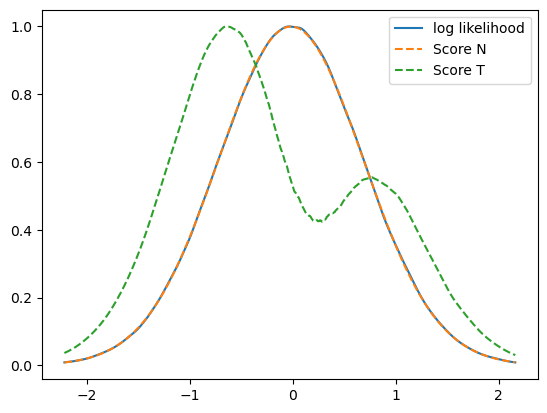

In [48]:
like_N = like_N/like_N.max()
like_T = like_T/like_T.max()
plt.plot(lam_grid,np.exp(loglike), label='log likelihood')
plt.plot(lam_grid,like_N,label='Score N',ls='--')
plt.plot(lam_grid,like_T,label='Score T',ls='--')
plt.legend()
plt.show()

/glade/derecho/scratch/vcooper/tmp/ipykernel_74697/2306747622.py:6: RuntimeWarning: divide by zero encountered in log
  loglike_S = np.log(kde(lam_from_S))


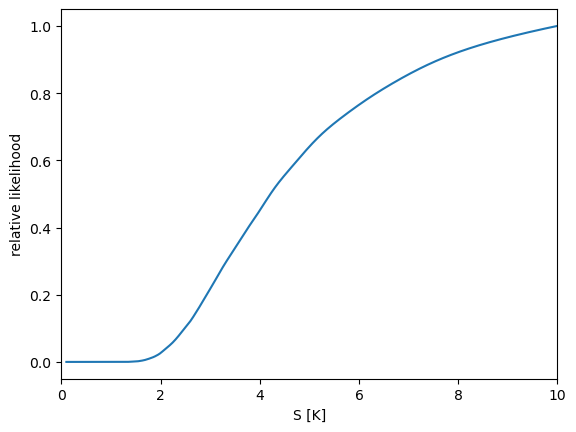

In [51]:
S_grid = np.linspace(0.1, 10, 500)  ## choose ECS range to plot

lam_from_S = -3.93 / S_grid
# lam_from_S = -F2x_ens / S_grid

loglike_S = np.log(kde(lam_from_S))
loglike_S -= np.nanmax(loglike_S)

In [59]:
%%time
### SCORE T version
### Score N version

S_like_N = np.zeros(len(S_grid))
S_like_T = np.zeros(len(S_grid))

for i,s in enumerate(S_grid):
    lam = -F2x_ens/s
    Npred = (lam - dlamb_ens)*Tdot_ens + Fdot_ens
    Tpred = (Ndot_ens - Fdot_ens)/(lam - dlamb_ens)
    S_like_N[i] = norm.pdf(Npred,loc=dNdt_mu,scale=dNdt_sig).mean()
    S_like_T[i] = norm.pdf(Tpred,loc=dTdt_mu,scale=dTdt_sig).mean()

S_like_N = S_like_N/S_like_N.max()
S_like_T = S_like_T/S_like_T.max()

CPU times: user 12 s, sys: 17.4 ms, total: 12 s
Wall time: 13.1 s


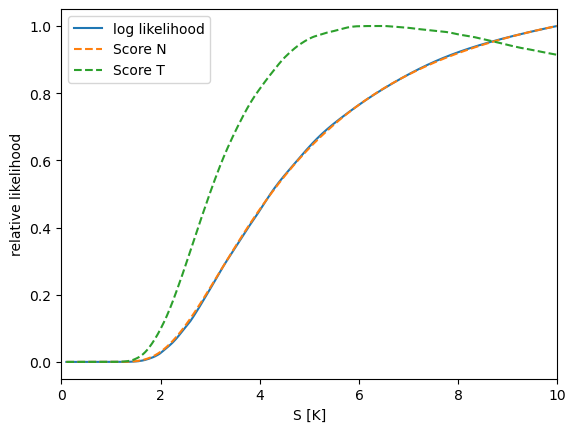

In [60]:
plt.plot(S_grid,np.exp(loglike_S), label='log likelihood')
plt.plot(S_grid,S_like_N,label='Score N',ls='--')
plt.plot(S_grid,S_like_T,label='Score T',ls='--')

plt.xlabel("S [K]")
plt.ylabel("relative likelihood")
plt.xlim(0,10)
plt.legend()
plt.show()

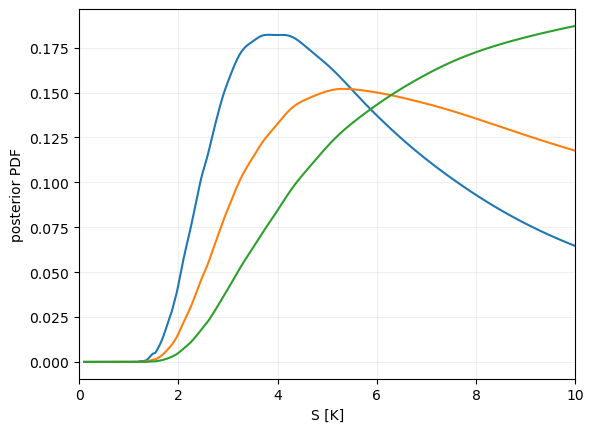

In [63]:
prior_mask = (lam_from_S >= -10) & (lam_from_S <= 10)

post_S = np.zeros_like(S_grid)

post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / S_grid[prior_mask]**2
## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)
plt.plot(S_grid, post_S, label='Uniform $\lambda$')

post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / S_grid[prior_mask]
## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)
plt.plot(S_grid, post_S, label='Log-uniform $\lambda$ and $S$')

post_S[prior_mask] = kde(lam_from_S[prior_mask]) * 3.93 / 1
## normalize area to 1
post_S = post_S / np.trapezoid(post_S, S_grid)
plt.plot(S_grid, post_S, label='Uniform $S$')

plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.show()

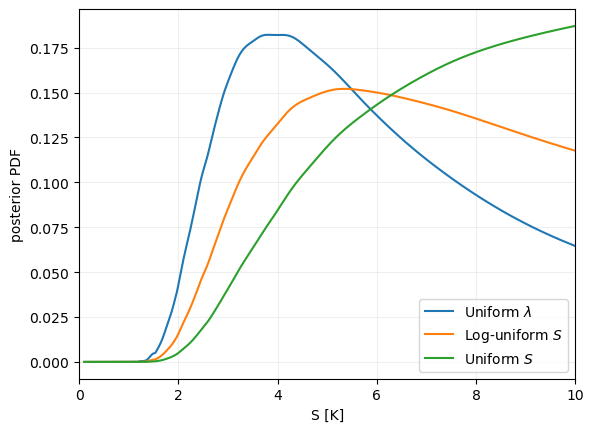

In [64]:
c = 3.93
lam_from_S = -c / S_grid

prior_mask = S_grid > 0

## uniform lambda prior
post_uniform_lam = np.zeros_like(S_grid)
post_uniform_lam[prior_mask] = kde(lam_from_S[prior_mask]) * c / S_grid[prior_mask]**2
post_uniform_lam /= np.trapezoid(post_uniform_lam, S_grid)

## log-uniform S prior, equivalently log-uniform |lambda|
post_log_uniform_S = np.zeros_like(S_grid)
post_log_uniform_S[prior_mask] = kde(lam_from_S[prior_mask]) / S_grid[prior_mask]
post_log_uniform_S /= np.trapezoid(post_log_uniform_S, S_grid)

## uniform S prior
post_uniform_S = np.zeros_like(S_grid)
post_uniform_S[prior_mask] = kde(lam_from_S[prior_mask])
post_uniform_S /= np.trapezoid(post_uniform_S, S_grid)

plt.plot(S_grid, post_uniform_lam, label='Uniform $\\lambda$')
plt.plot(S_grid, post_log_uniform_S, label='Log-uniform $S$ and $\lambda$')
plt.plot(S_grid, post_uniform_S, label='Uniform $S$')

plt.grid(alpha=0.2)
plt.xlabel("S [K]")
plt.ylabel("posterior PDF")
plt.xlim(0, 10)
plt.legend()
plt.show()

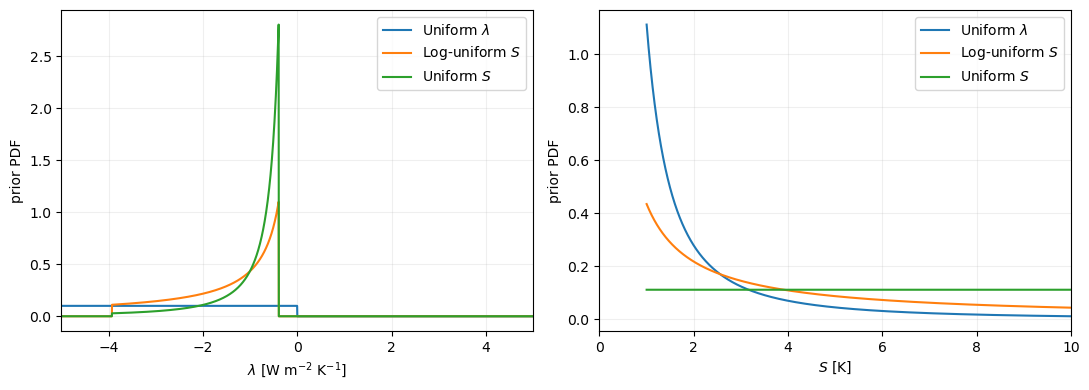

In [69]:
c = 3.93
S_min, S_max = 1., 10

S_grid = np.linspace(S_min, S_max, 5000)
lam_grid = np.linspace(-10, 10, 5000)

def normalize(pdf, x):
    area = np.trapezoid(pdf, x)
    return pdf / area if area > 0 else pdf

## ---------- priors in S space ----------

lam_from_S = -c / S_grid

pS_uniform_lam = np.zeros_like(S_grid)
mask = (lam_from_S >= -10) & (lam_from_S < 0)
pS_uniform_lam[mask] = c / S_grid[mask]**2
pS_uniform_lam = normalize(pS_uniform_lam, S_grid)

pS_log_uniform_S = np.zeros_like(S_grid)
mask = (S_grid >= S_min) & (S_grid <= S_max)
pS_log_uniform_S[mask] = 1 / S_grid[mask]
pS_log_uniform_S = normalize(pS_log_uniform_S, S_grid)

pS_uniform_S = np.zeros_like(S_grid)
mask = (S_grid >= S_min) & (S_grid <= S_max)
pS_uniform_S[mask] = 1
pS_uniform_S = normalize(pS_uniform_S, S_grid)


## ---------- priors in lambda space ----------

S_from_lam = -c / lam_grid

pL_uniform_lam = np.zeros_like(lam_grid)
mask = (lam_grid >= -10) & (lam_grid < 0)
pL_uniform_lam[mask] = 1
pL_uniform_lam = normalize(pL_uniform_lam, lam_grid)

pL_log_uniform_S = np.zeros_like(lam_grid)
mask = (S_from_lam >= S_min) & (S_from_lam <= S_max)
pL_log_uniform_S[mask] = 1 / np.abs(lam_grid[mask])
pL_log_uniform_S = normalize(pL_log_uniform_S, lam_grid)

pL_uniform_S = np.zeros_like(lam_grid)
mask = (S_from_lam >= S_min) & (S_from_lam <= S_max)
pL_uniform_S[mask] = c / lam_grid[mask]**2
pL_uniform_S = normalize(pL_uniform_S, lam_grid)


## ---------- plot ----------

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(lam_grid, pL_uniform_lam, label=r'Uniform $\lambda$')
axs[0].plot(lam_grid, pL_log_uniform_S, label=r'Log-uniform $S$')
axs[0].plot(lam_grid, pL_uniform_S, label=r'Uniform $S$')
axs[0].set_xlabel(r'$\lambda$ [W m$^{-2}$ K$^{-1}$]')
axs[0].set_ylabel('prior PDF')
axs[0].set_xlim(-5, 5)
axs[0].grid(alpha=0.2)
axs[0].legend()

axs[1].plot(S_grid, pS_uniform_lam, label=r'Uniform $\lambda$')
axs[1].plot(S_grid, pS_log_uniform_S, label=r'Log-uniform $S$')
axs[1].plot(S_grid, pS_uniform_S, label=r'Uniform $S$')
axs[1].set_xlabel(r'$S$ [K]')
axs[1].set_ylabel('prior PDF')
axs[1].set_xlim(0, 10)
axs[1].grid(alpha=0.2)
axs[1].legend()

plt.tight_layout()
plt.show()

## KEEP GOING HERE 
https://chatgpt.com/c/6a062dcc-fc3c-83ea-9593-37ce2aa718f3